# Exploratory Data Analysis (EDA) and Visualization

## Vaccination Impact on Cases


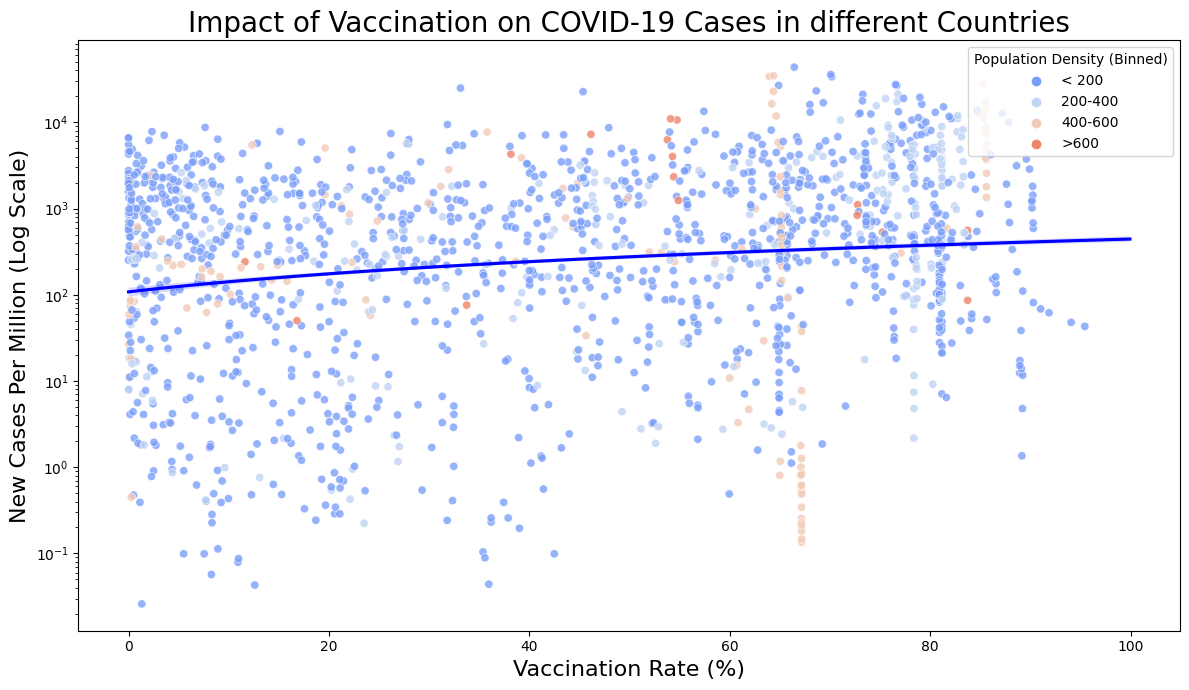

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = pd.read_csv("owid_covid_data.csv", low_memory=False)

# Filter data for meaningful values
filtered_data = data.dropna(subset=['people_fully_vaccinated_per_hundred', 'new_cases_per_million', 'population_density'])
filtered_data = filtered_data[filtered_data['people_fully_vaccinated_per_hundred'] <= 100]

# Sample a fraction of the data to reduce overlap
sampled_data = filtered_data.sample(frac=0.2, random_state=42)

# Group population density into bins for better legend readability
density_bins = pd.cut(
    sampled_data['population_density'],
    bins=[0, 200, 400, 600, 1000],
    labels=['< 200', '200-400', '400-600', '>600']
)
sampled_data['density_category'] = density_bins

# Create a scatterplot with binned population density
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(
    data=sampled_data,
    x='people_fully_vaccinated_per_hundred',
    y='new_cases_per_million',
    hue='density_category',  # Use binned density for legend
    alpha=0.8,
    palette='coolwarm'

)

# Add regression line to show trends
sns.regplot(
    data=filtered_data,
    x='people_fully_vaccinated_per_hundred',
    y='new_cases_per_million',
    scatter=False,
    color='blue',
)

# Log scale for y-axis to handle extreme values
plt.yscale('log')
plt.title('Impact of Vaccination on COVID-19 Cases in different Countries', fontsize=20)
plt.xlabel('Vaccination Rate (%)', fontsize=16)
plt.ylabel('New Cases Per Million (Log Scale)', fontsize=16)
plt.legend(title='Population Density (Binned)', loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


## Vaccination Impact on Deaths

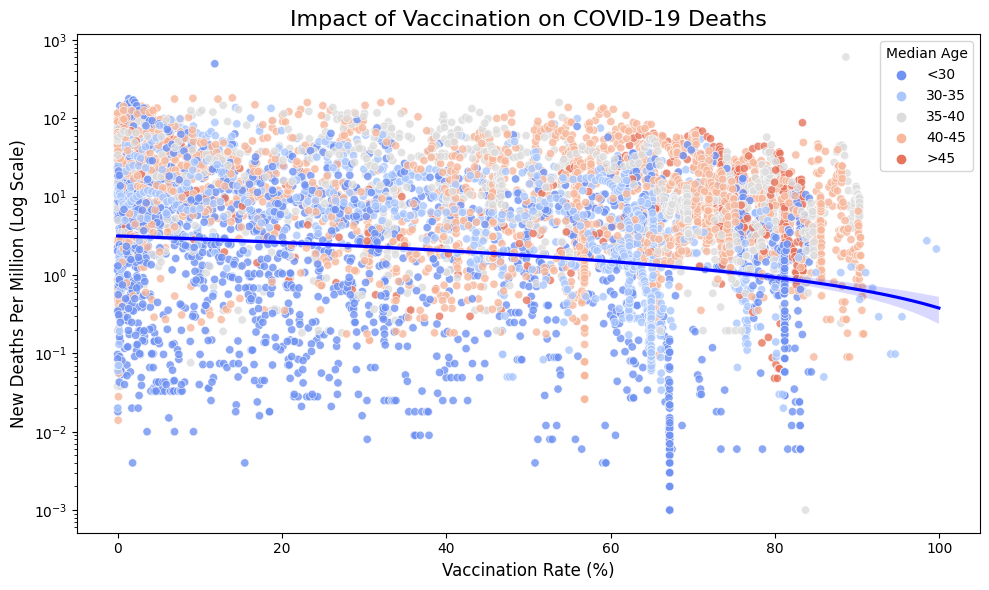

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = pd.read_csv("owid_covid_data.csv")

# Filter data for meaningful values
filtered_data = data.dropna(subset=['people_fully_vaccinated_per_hundred', 'new_deaths_per_million', 'median_age'])
filtered_data = filtered_data[filtered_data['people_fully_vaccinated_per_hundred'] <= 100]

# Bin median age into categories for better legend readability
age_bins = pd.cut(
    filtered_data['median_age'],
    bins=[0, 30, 35, 40, 45, 50],
    labels=['<30', '30-35', '35-40', '40-45', '>45']
)
filtered_data.loc[:, 'age_category'] = age_bins  # Use .loc[] to avoid warnings

# Create the scatterplot with binned age categories
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_data,
    x='people_fully_vaccinated_per_hundred',
    y='new_deaths_per_million',
    hue='age_category',  # Use binned age for legend
    alpha=0.8,
    palette='coolwarm'
    
)

# Add regression line to show trends
sns.regplot(
    data=filtered_data,
    x='people_fully_vaccinated_per_hundred',
    y='new_deaths_per_million',
    scatter=False,
    color='blue',
    line_kws={"label": "Trend Line"}
)

# Add title, labels, and legend
plt.yscale('log')
plt.title('Impact of Vaccination on COVID-19 Deaths', fontsize=16)
plt.xlabel('Vaccination Rate (%)', fontsize=12)
plt.ylabel('New Deaths Per Million (Log Scale)', fontsize=12)
plt.legend(title='Median Age', loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


## Healthcare Resources and Mortality

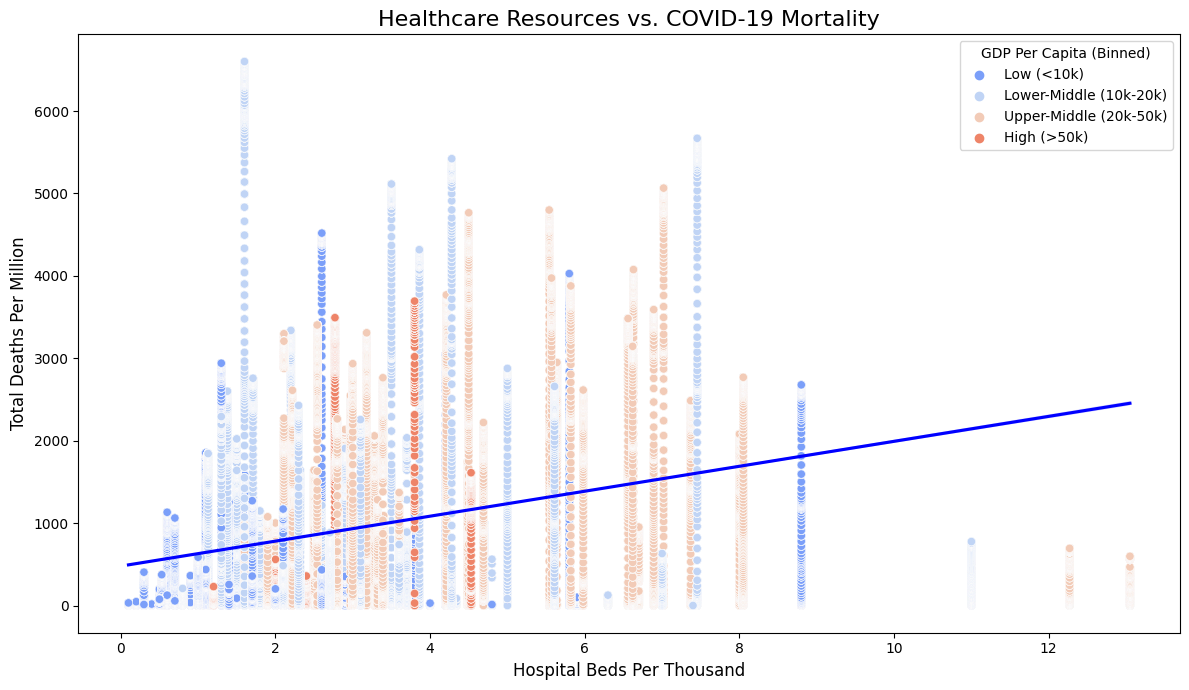

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
data = pd.read_csv("owid_covid_data.csv")

# Filter data for meaningful values
filtered_data = data.dropna(subset=['hospital_beds_per_thousand', 'total_deaths_per_million', 'gdp_per_capita']).copy()  # Explicit deep copy

# Bin GDP per capita into categories for better legend readability
gdp_bins = pd.cut(
    filtered_data['gdp_per_capita'],
    bins=[0, 10000, 20000, 50000, 100000],
    labels=['Low (<10k)', 'Lower-Middle (10k-20k)', 'Upper-Middle (20k-50k)', 'High (>50k)']
)
filtered_data['gdp_category'] = gdp_bins  # No warning because filtered_data is a copy

# Create the scatterplot with binned GDP categories
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=filtered_data,
    x='hospital_beds_per_thousand',
    y='total_deaths_per_million',
    hue='gdp_category',  # Use binned GDP for legend
    alpha=0.7,
    palette='coolwarm'
)

# Add regression line to show trends
sns.regplot(
    data=filtered_data,
    x='hospital_beds_per_thousand',
    y='total_deaths_per_million',
    scatter=False,
    color='blue',
    line_kws={"label": "Trend Line"}
)

# Add title, labels, and legend
plt.title('Healthcare Resources vs. COVID-19 Mortality', fontsize=16)
plt.xlabel('Hospital Beds Per Thousand', fontsize=12)
plt.ylabel('Total Deaths Per Million', fontsize=12)
plt.legend(title='GDP Per Capita (Binned)', loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


## Economic Factors and Outcomes

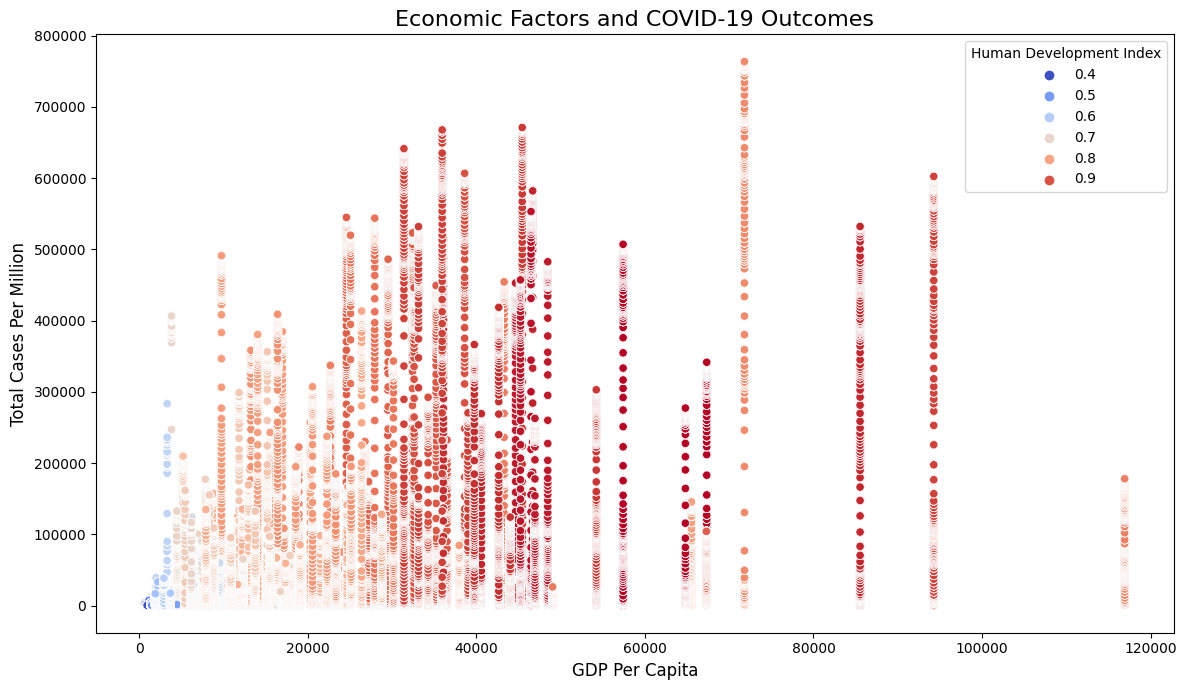

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("owid_covid_data.csv")

#Filter data for meaningful values
filtered_data = data.dropna(subset=['gdp_per_capita', 'total_cases_per_million', 'human_development_index'])

# Create the scatterplot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=filtered_data,
    x='gdp_per_capita',
    y='total_cases_per_million',
    hue='human_development_index',  # Human development index as color
    palette='coolwarm'
)
plt.title('Economic Factors and COVID-19 Outcomes', fontsize=16)
plt.xlabel('GDP Per Capita', fontsize=12)
plt.ylabel('Total Cases Per Million', fontsize=12)
plt.legend(title='Human Development Index', loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()